### Task 5: state-space representation
Bring the damped system into state-space, by forming the matrices $A$, $B$, $C$ and $D$ for absolute vibration acceleration output. Then use the function scipy.signal.StateSpace to create the corresponding system model in Python, and simulate using either scipy.signal.lsim or the same approach as above (or both). You will obtain the damped structural response under the same excitation of Task 2. Extract also the relative displacements and velocities and comment on the differences between these and the ones calculated in Task 2...

MATRIX A == STATE MATRIX
MATRIX B == INPUT MATRIX
MATRIX C == OUTPUT MATRIX
MATRIX D == FEEDTHROUGH MATRIX

In [25]:
mass_matrix = M
mass_matrix_inverse = np.linalg.inv(M)
stiffness_matrix = K
damping_matrix = (alpha_value*mass_matrix) + (beta_value*stiffness_matrix)

matrix_A = np.block([[np.zeros((3,3)), np.eye(3)],
                     [-mass_matrix_inverse @ stiffness_matrix, -mass_matrix_inverse @ damping_matrix]])

matrix_B = np.vstack([np.zeros((3,1)),-np.ones((3,1))])
matrix_C = np.hstack([-mass_matrix_inverse @ stiffness_matrix, -mass_matrix_inverse @ damping_matrix])
matrix_D = np.zeros((3,1))

In [26]:
state_representation = scipy.signal.StateSpace(matrix_A, matrix_B, matrix_C, matrix_D)

In [ ]:
ag = ground_acceleration * 9.81
scipy.signal.lsim(state_representation, U= ag, T= time)


In [ ]:

time_values_of_output, system_response, time_evolution_of_state_vector = scipy.signal.lsim(state_representation, U=ag , T= time)

In [41]:
print(np.shape(time_evolution_of_state_vector))
print(np.shape(system_response))
print(np.shape(time_values_of_output))
print(data.shape)

(2500, 6)
(2500, 3)
(2500,)
(2500, 2)


In [ ]:
print(time_values_of_output)
print(system_response)              # values for absolute acceleration
print(time_evolution_of_state_vector)

In [43]:
displacement = time_evolution_of_state_vector[:, :3]
velocity = time_evolution_of_state_vector[:, 3:]

In [44]:
print(displacement)
print(velocity)

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.66296746e-06 -1.66502271e-06 -1.66502390e-06]
 [-1.30722754e-05 -1.31075403e-05 -1.31075855e-05]
 ...
 [ 3.27465452e-02  6.89525713e-02  1.01010139e-01]
 [ 3.30787996e-02  6.86548494e-02  9.99839089e-02]
 [ 3.33758536e-02  6.83411960e-02  9.88883331e-02]]
[[ 0.          0.          0.        ]
 [-0.00021929 -0.00021968 -0.00021968]
 [-0.00108336 -0.00108728 -0.00108728]
 ...
 [ 0.01742035 -0.01448991 -0.04953467]
 [ 0.01577991 -0.01527114 -0.05305538]
 [ 0.01385645 -0.01613178 -0.0565146 ]]


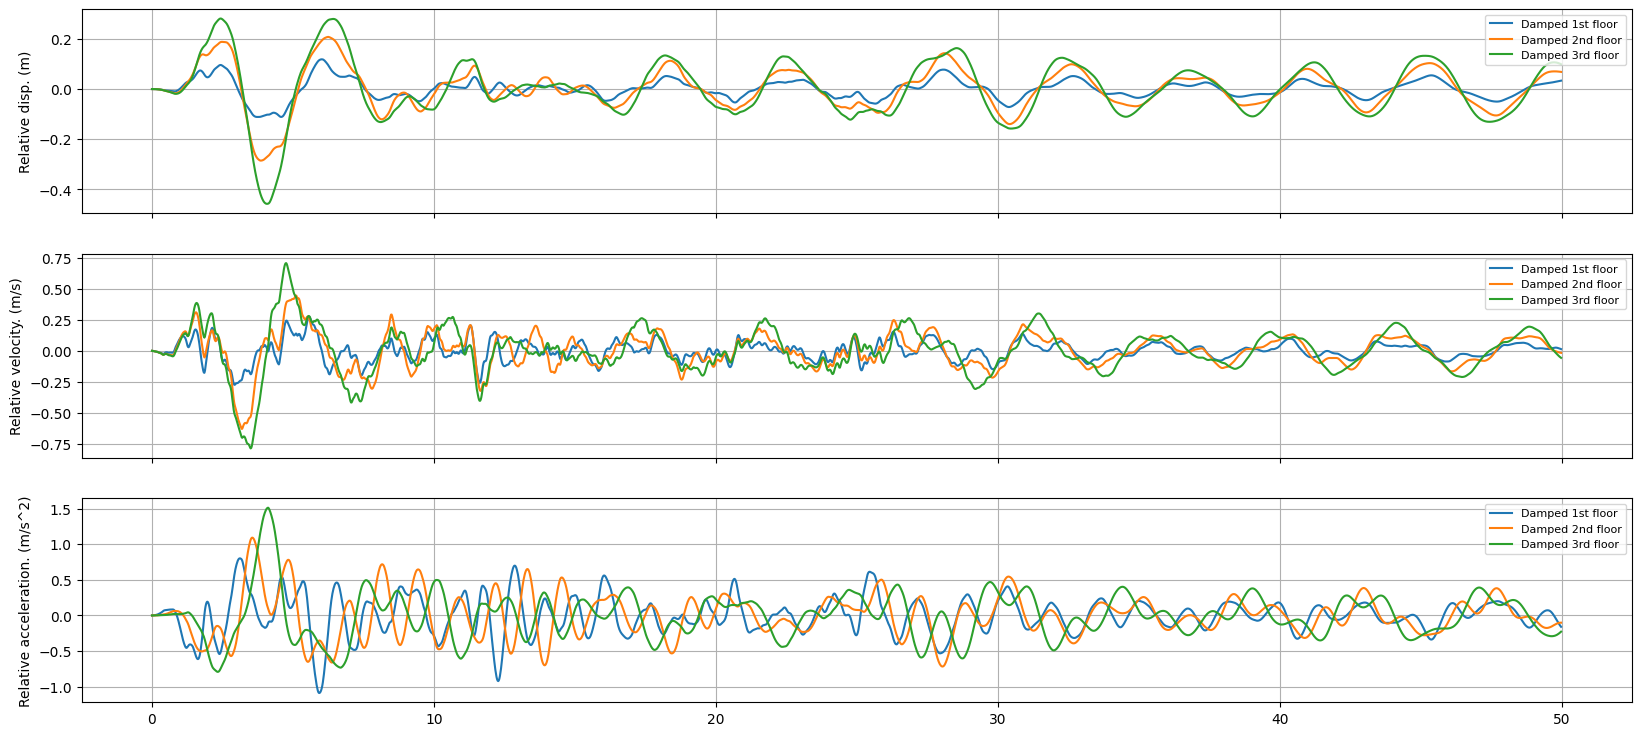

In [49]:
fig, axes = plt.subplots(3, 1, figsize=(20, 9), sharex=True)
labels = ['1st floor', '2nd floor', '3rd floor']

# Relative displacements
for i in range(3):
    #axes[0].plot(time, displacement[:, i], '--', label=f'Undamped {labels[i]}')
    axes[0].plot(time, displacement[:, i], '-', label=f'Damped {labels[i]}')
    axes[1].plot(time, velocity[:, i], '-', label=f'Damped {labels[i]}')
    axes[2].plot(time, system_response[:, i], '-', label=f'Damped {labels[i]}')
axes[0].set_ylabel('Relative disp. (m)')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True)

axes[1].set_ylabel('Relative velocity. (m/s)')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True)

axes[2].set_ylabel('Relative acceleration. (m/s^2)')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(True)